In [27]:
from folktables import ACSDataSource
import folktables
import numpy as np
import pandas as pd

columns = ['AGEP', 'SCHL', 'MAR', 'SEX', 'DIS', 'MIG', 'CIT', 'MIL', 'NATIVITY', 'RELP', 'DEAR', 'DEYE', 'DREM', 'RAC1P', 'PAP', 'HISP', 'PWGTP', 'HICOV']

def filter(data):
    """
    Filters for the employment prediction task
    """
    df = data
    df = df[df['AGEP'] > 16]
    df = df[df['AGEP'] < 90]
    df = df[df['PWGTP'] >= 1]
    return df

ACSCustom = folktables.BasicProblem(
    features=columns,
    target="HICOV",
    target_transform=lambda x: x == 1,
    group='RAC1P',
    preprocess=filter,
    postprocess=lambda x: np.nan_to_num(x, -1),
)

maps = pd.read_csv('/home/nick/RL_guided/preprocessing/ACS/PUMS_Data_Dictionary_2018.csv', header=None)
ancestry_map = maps[maps[1] == 'ANC1P']

#ancestry_map.columns=[0,1,2,3,4,'Code', 'Ancestry']
#ancestry_map = ancestry_map.drop(columns=[0,1,2,3,4])

#state_map = maps[maps[1] == 'ST']
#state_map.columns=[0,1,2,3,4,'Code', 'State']
#state_map = state_map.drop(columns=[0,1,2,3,4])

data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=['TN'], download=True)

In [28]:
#cols = acs_data.columns.values
#cols.sort()
#cols

In [29]:
features, label, group = ACSCustom.df_to_numpy(acs_data)
features = pd.DataFrame(features, columns=columns)#.sample(50_000)

In [30]:
cat_cols = ["MIL", 'RAC1P', 'CIT'] #['MAR', 'CIT', 'RAC1P', 'MIL', 'GCL']#, 'ST']
bin_cols = ['DIS', 'DEAR', 'DEYE', 'DREM', 'NATIVITY', 'MIG', 'RELP', 'SEX', 'HISP', 'HICOV']
cont_cols = ['AGEP', 'SCHL', 'PAP']

renaming = {"AGEP": "Age", 
            'SCHL': 'Years of School', 
            'MAR':'Marital Status', 
            "RELP":'Institutionalized', 
            'DIS': "Disability",
            'CIT': 'Citizenship',
            'MIG': '1yr Mobility',
            'MIL': 'Military', 
            'DEAR': 'Hearing Difficulty',
            'DEYE': "Vision Difficulty",
            'DREM': 'Cognitive Difficulty',
            'RAC1P': 'Race',
            'SEX': 'Male',    
            'NATIVITY': 'Native',
            'HICOV': "Health Insurance",
            #'HHL': 'Household Language',
            'PAP': 'Public Assistance Income',
            #'GCL': 'Grandparents Living with Grandchildren',
            #'ST': 'State', 
            #'ANC1P':'Ancestry',
            'HISP':'Hispanic/Latino',
            'ST': 'State'
            }

mappings = {
    #'MAR': {1:'Married', 2: 'Previously Married', 3: 'Previously Married', 4: 'Previously Married', 5: 'Never Married'},
    'CIT': {1:'Born Citizen', 2: 'Born Citizen', 3: 'Born Citizen', 4: 'Naturalized', 5:'Not a citizen'},
    'MIL': {1:"Current Military", 2:'Former Military', 3: 'Current Military', 4:'Never Military'},
    'RAC1P': {1:'White', 2:'Black/African American', 3:'Other', 4:"Other", 5:'Other', 6:'Asian', 7:'Other', 8:"Other",9:'Two or More'},
    #'HHL': {1: 'English', 2:'Spanish',3:'Other Indo-European Language',4:'Asian and Pacific Island Language', 5:'Other'}
    #'ST': {47.0: "Tennessee", 12.0: 'Florida', 48.0:'Texas'}
    #'GCL': {0: 'N/A', 1:'Yes', 2:'No'},
    #'ANC1P': ancestry_map.set_index('Code').to_dict()['Ancestry'],
    #'ST': state_map.set_index('Code').to_dict()['State'],
}

features['MIG'] = 2 - (features['MIG'].astype(int) == 1).astype(int)
features['RELP'] = 2 - (features['RELP'].astype(int) == 16).astype(int)

features


,AGEP,SCHL,MAR,SEX,DIS,MIG,CIT,MIL,NATIVITY,RELP,DEAR,DEYE,DREM,RAC1P,PAP,HISP,PWGTP,HICOV
0,72.0,5.0,5.0,1.0,1.0,1,1.0,4.0,1.0,1,2.0,2.0,2.0,1.0,0.0,1.0,20.0,1.0
1,41.0,18.0,5.0,1.0,1.0,1,1.0,4.0,1.0,1,2.0,1.0,1.0,1.0,0.0,1.0,69.0,2.0
2,18.0,18.0,5.0,2.0,2.0,2,1.0,4.0,1.0,2,2.0,2.0,2.0,1.0,0.0,1.0,44.0,1.0
3,26.0,16.0,5.0,1.0,2.0,2,1.0,4.0,1.0,1,2.0,2.0,2.0,1.0,0.0,2.0,11.0,1.0
4,78.0,20.0,3.0,2.0,1.0,1,1.0,4.0,1.0,1,2.0,2.0,2.0,1.0,0.0,1.0,22.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54447,31.0,19.0,1.0,1.0,2.0,1,1.0,4.0,1.0,2,2.0,2.0,2.0,1.0,0.0,1.0,60.0,1.0
54448,30.0,18.0,1.0,2.0,2.0,1,1.0,4.0,1.0,2,2.0,2.0,2.0,1.0,0.0,1.0,69.0,1.0
54449,29.0,21.0,3.0,1.0,2.0,2,1.0,4.0,1.0,2,2.0,2.0,2.0,1.0,0.0,1.0,79.0,1.0
54450,75.0,16.0,2.0,2.0,2.0,1,1.0,4.0,1.0,2,2.0,2.0,2.0,1.0,0.0,1.0,39.0,1.0


In [31]:
for k,v in mappings.items():
    features[k] = features[k].astype(int).apply(lambda x: mappings[k][x])

for col in bin_cols:
    features[col] = 2-features[col]

features = features.rename(columns=renaming)
#features['Employed'] = label.astype(int)

In [32]:
# Most public assistance is 0. Encode this variable manually to enable easier learning
features.loc[:,'Public Assistance Binary'] = (features['Public Assistance Income'] != 0).astype(int)
bin_cols.append('Public Assistance Binary')

# Encode ethnicity as Hispanic/Latino vs not (as with Census)
features['Hispanic/Latino'] = (features['Hispanic/Latino'] != 1).astype(int)
bin_cols.append('Hispanic/Latino')

In [33]:
# Convert categorical columns to series of binary columns
for c in cat_cols:
    col = renaming[c]
    temp = pd.get_dummies(features[col]).astype(int)

    features = pd.concat([features, temp], axis=1).drop(columns=[col])


In [34]:
features.columns

Index(['Age', 'Years of School', 'Marital Status', 'Male', 'Disability',
       '1yr Mobility', 'Native', 'Institutionalized', 'Hearing Difficulty',
       'Vision Difficulty', 'Cognitive Difficulty', 'Public Assistance Income',
       'Hispanic/Latino', 'PWGTP', 'Health Insurance',
       'Public Assistance Binary', 'Current Military', 'Former Military',
       'Never Military', 'Asian', 'Black/African American', 'Other',
       'Two or More', 'White', 'Born Citizen', 'Naturalized', 'Not a citizen'],
      dtype='object')

In [35]:
from sklearn.model_selection import train_test_split

# Make train/test split
np.random.seed(42)
train, test = train_test_split(features, test_size=0.2)
val, test = train_test_split(test, test_size=0.5)

train.to_csv('data/unnormalized_train.csv')
val.to_csv('data/unnormalized_val.csv')
test.to_csv('data/unnormalized_test.csv')


# Normalize continuous columns to [0,1]
min_max_log = {}
cols = ['Age', 'Years of School', 'Public Assistance Income']
for col_name in cols:
    col_value = np.array(train[col_name])
    min_max_log[col_name] = [np.min(col_value), np.max(col_value)]

    # Train
    norm_col_value = (col_value - min_max_log[col_name][0]) / (min_max_log[col_name][1] - min_max_log[col_name][0])
    train[col_name] = list(norm_col_value)

    # Test
    col_value_test = np.array(test[col_name])
    norm_col_value_test = (col_value_test - min_max_log[col_name][0]) / (min_max_log[col_name][1] - min_max_log[col_name][0])
    test[col_name] = list(norm_col_value_test)

    # Val
    col_value_val = np.array(val[col_name])
    norm_col_value_test = (col_value_val - min_max_log[col_name][0]) / (min_max_log[col_name][1] - min_max_log[col_name][0])
    val[col_name] = list(col_value_val)

print(min_max_log)
np.save('data/min_max_log.npy', min_max_log)


# To reverse normalization
#for key, min_max in min_max_log.items():
#    min_, max_ = min_max[0], min_max[1]
#    col_values = np.array(training_data_df[key])
#    training_data_df[key] = (1 - col_values)*min_ + col_values*max_
#    col_values = np.array(testing_data_df[key])
#    testing_data_df[key] = (1 - col_values)*min_ + col_values*max_

{'Age': [np.float64(17.0), np.float64(89.0)], 'Years of School': [np.float64(1.0), np.float64(24.0)], 'Public Assistance Income': [np.float64(0.0), np.float64(12200.0)]}


In [36]:
train.to_csv('data/normalized_train.csv')
val.to_csv('data/normalized_val.csv')
test.to_csv('data/normalized_test.csv')


In [37]:
train.shape, val.shape, test.shape

((43561, 27), (5445, 27), (5446, 27))

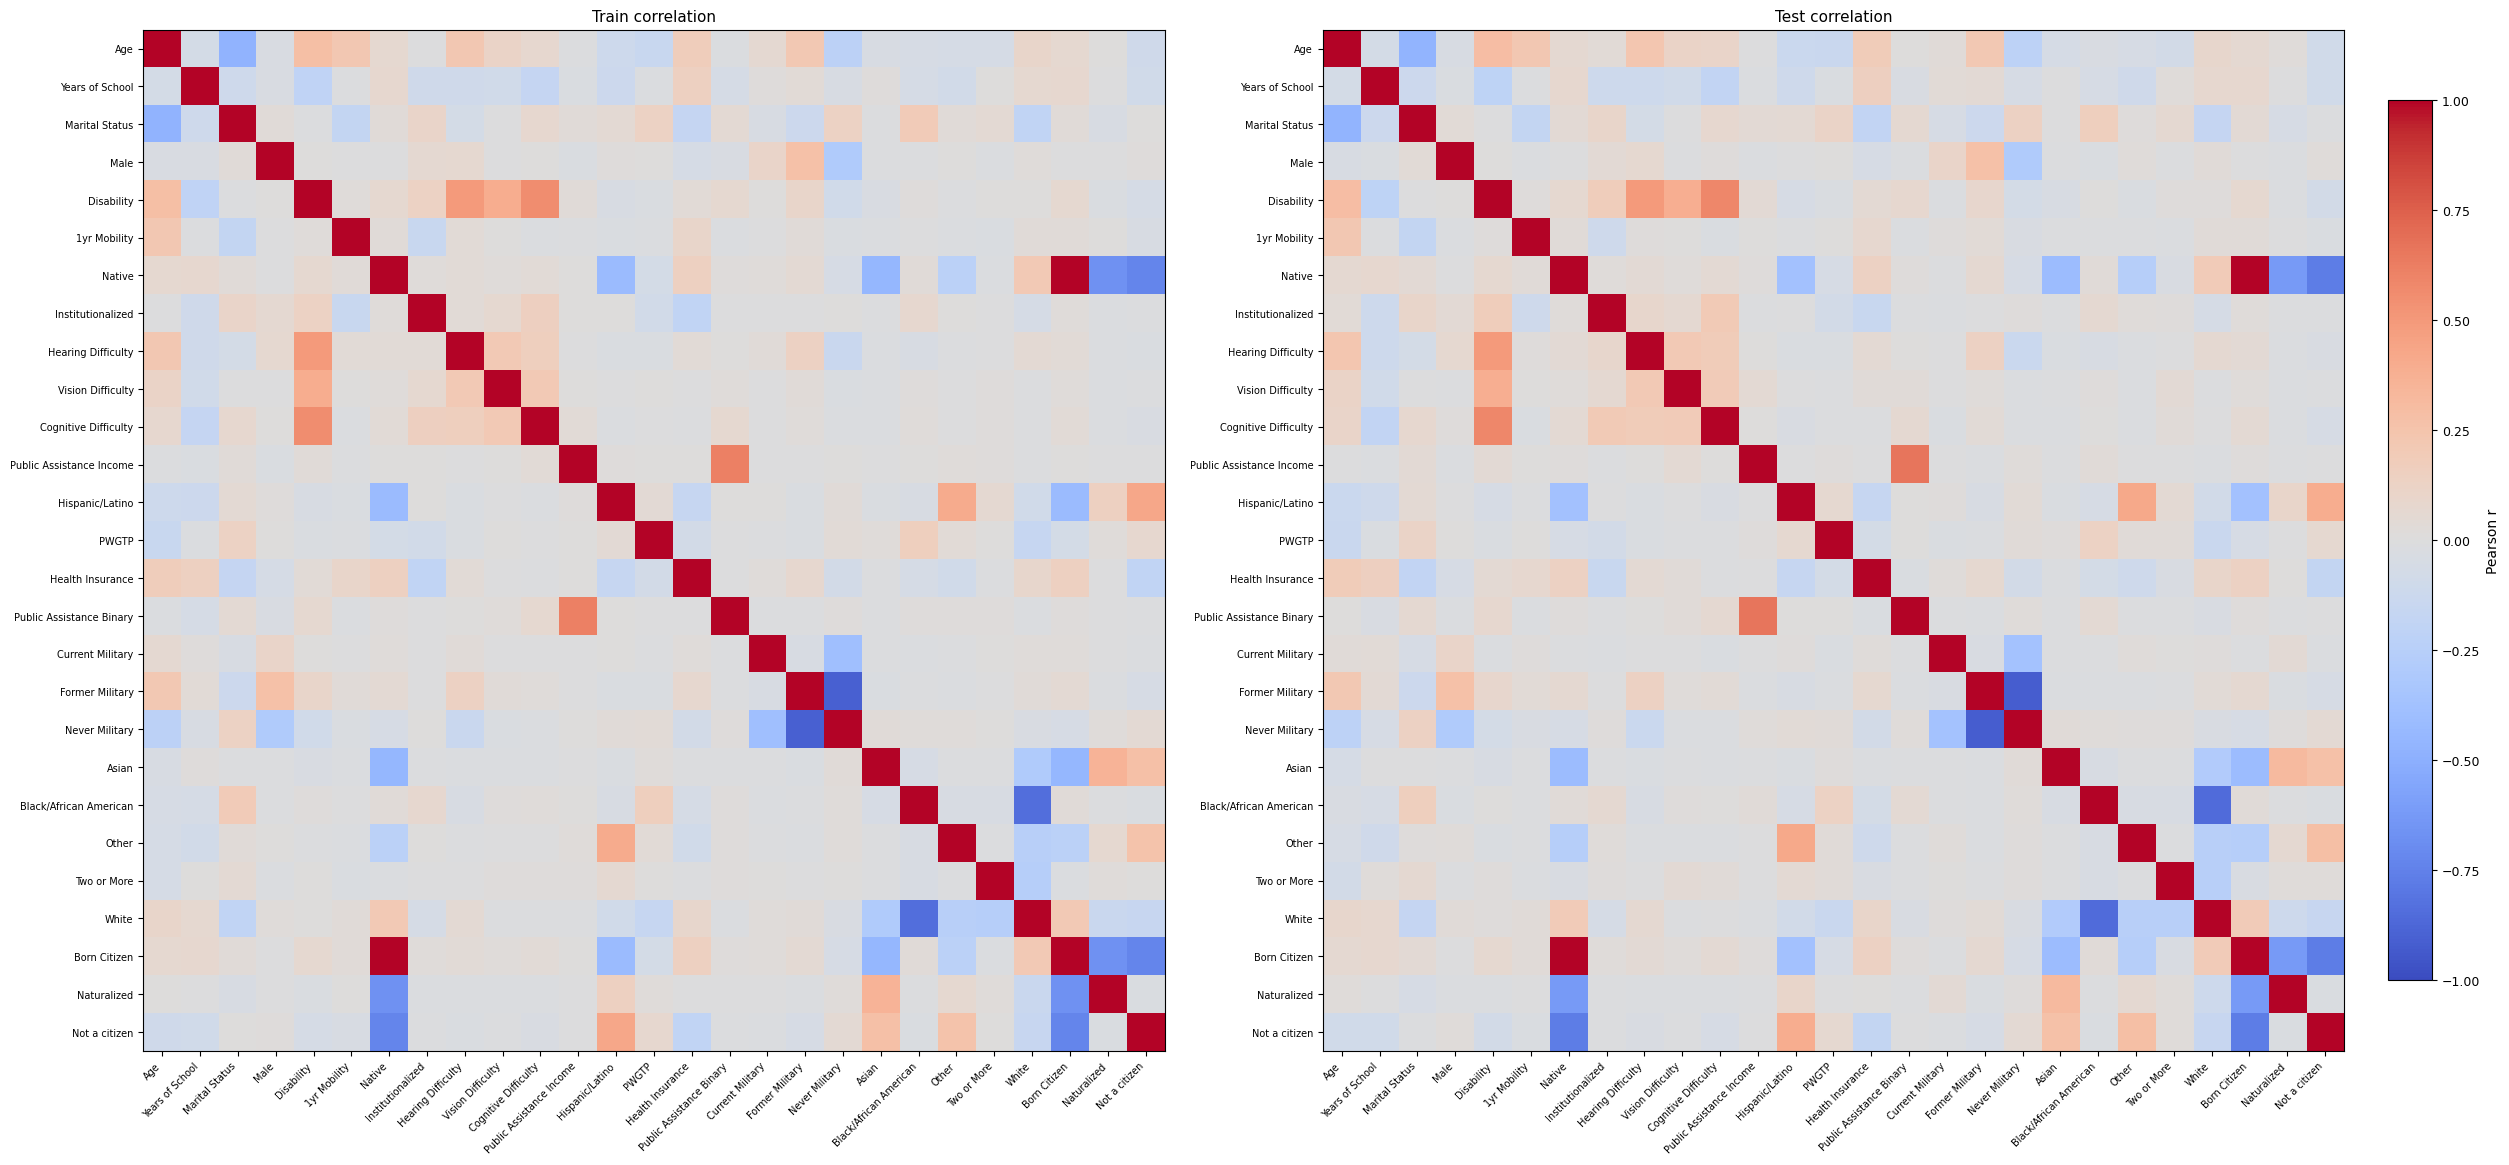

In [38]:
train_corr = train.corr()
test_corr  = test.corr().fillna(0) # beacause 0 participants with Race Alaskan Native in test data
n = train_corr.shape[1]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(25,20), constrained_layout=True)
for ax, corr, title in zip(axes, (train_corr, test_corr), ("Train correlation", "Test correlation")):
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Pearson r").ax.tick_params(labelsize=9)